<a href="https://colab.research.google.com/github/stnewaz/Computer-Vision-Project/blob/another_test/ComputerVisionProject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<center><h1> <b> Cloud Classifcation With YOLO 11 <b> </h1></center>

In the previous lecture, you were asked to make your own custom datasets for a project you want to work on. Today we will explore how to finetune YOLO on a certain dataset.  

Importing required Libraries

In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
# import tensorflow as tf
# from tensorflow import keras
import cv2
import seaborn as sns
import glob
import xml.etree.ElementTree as ET
from PIL import Image
import os
import shutil

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Dataset Description






Fruit Images for Object Detection

available on kaggle => https://www.kaggle.com/datasets/mbkinaci/fruit-images-for-object-detection


- 240 images in train folder. 60 images in test folder.

- 3 different fruits:

    - Apple

    - Banana

    - Orange

The labels are in xml format, which is Extensible markup language.Storing image dataset labels in XML format is quite common. XML provides a clear, hierarchical structure which is ideal for representing the complex data associated with image labels. This includes not just the class of the object, but potentially a wealth of other information like bounding box coordinates, object IDs, and additional metadata.


Training and Validation

First install and import

In [3]:
%pip install ultralytics
import ultralytics
ultralytics.checks()

Ultralytics 8.3.223 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 39.1/112.6 GB disk)


In [4]:
from ultralytics import YOLO

## Training YOLO - Lab Example

We are going to select small pretrained (on COCO dataset) model of YOLOv8

In [13]:
model = YOLO('yolo11s-cls.pt') # pretrained model

In [15]:
model_tuned = YOLO('yolo11s-cls.pt') # pretrained model

In [16]:
%%writefile config.yaml
path: /content/drive/MyDrive/archive (2)/data
train: train/
# test: test/
val: val/

# Classes
nc: 11 # replace based on your dataset's number of classes

# Class names
# replace all class names with your own classes' names
names:
 0: ac
 1: as
 2: cb
 3: cc
 4: ci
 5: cs
 6: ct
 7: cu
 8: ns
 9: sc
 10: st

Overwriting config.yaml


Please look at [Yolo train Docs](https://docs.ultralytics.com/modes/train/#train-settings) for hyperparameters for model tuning and configuration, e.g. lr0, imgsz, model etc.

In [ ]:
model.train(data="C:\\Users\Selena\\Documents\\school\\iat360\\cv_project\\data_original_valupdate\\data",epochs=5,patience=5,batch=8, lr0=0.0005,imgsz=400, plots=True)

<>:1: SyntaxWarning: "\S" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\S"? A raw string is also an option.
<>:1: SyntaxWarning: "\S" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\S"? A raw string is also an option.
C:\Users\Selena\AppData\Local\Temp\ipykernel_16708\2452195428.py:1: SyntaxWarning: "\S" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\S"? A raw string is also an option.
  model.train(data="C:\\Users\Selena\\Documents\\school\\iat360\\cv_project\\data_original_valupdate\\data",epochs=5,patience=5,batch=8, lr0=0.0005,imgsz=400, plots=True)


Ultralytics 8.3.223  Python-3.14.0 torch-2.9.0+cpu CPU (AMD Ryzen 5 5600X 6-Core Processor)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=C:\Users\Selena\Documents\school\iat360\cv_project\data_original_valupdate\data, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=5, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=400, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0005, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11s-cls.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overl

ultralytics.utils.metrics.ClassifyMetrics object with attributes:

confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x000001CF043DF9B0>
curves: []
curves_results: []
fitness: 0.6540404111146927
keys: ['metrics/accuracy_top1', 'metrics/accuracy_top5']
results_dict: {'metrics/accuracy_top1': 0.40909090638160706, 'metrics/accuracy_top5': 0.8989899158477783, 'fitness': 0.6540404111146927}
save_dir: WindowsPath('C:/Users/Selena/runs/classify/train')
speed: {'preprocess': 0.0015500000020006385, 'inference': 20.681953535351955, 'loss': 5.353535696008064e-05, 'postprocess': 0.00016313130588675238}
task: 'classify'
top1: 0.40909090638160706
top5: 0.8989899158477783

In [ ]:
# old using yolo8
model_tuned.train(data="S:/important_backup/school_backup/iat360/archive/data/train",epochs=30,patience=8,batch=16, lr0=0.0005,imgsz=640)

New https://pypi.org/project/ultralytics/8.3.223 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.218  Python-3.13.7 torch-2.9.0+cpu CPU (AMD Ryzen 7 PRO 5875U with Radeon Graphics)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=S:/important_backup/school_backup/iat360/archive/data/train, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0005, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11s-cls.pt, momentum=0.937, mosaic=1.0, multi_sc

ultralytics.utils.metrics.ClassifyMetrics object with attributes:

confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x000002658FF10830>
curves: []
curves_results: []
fitness: 0.7526652216911316
keys: ['metrics/accuracy_top1', 'metrics/accuracy_top5']
results_dict: {'metrics/accuracy_top1': 0.5628997683525085, 'metrics/accuracy_top5': 0.9424306750297546, 'fitness': 0.7526652216911316}
save_dir: WindowsPath('C:/Users/selen/runs/classify/train3')
speed: {'preprocess': 0.0012904051383500542, 'inference': 115.61718805971594, 'loss': 4.71217698777027e-05, 'postprocess': 0.0001362472552178638}
task: 'classify'
top1: 0.5628997683525085
top5: 0.9424306750297546

In [17]:
model_tuned.train(data="/content/drive/MyDrive/archive (2)/data",epochs=15,patience=5,batch=8, lr0=0.0005,imgsz=400)

Ultralytics 8.3.223 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/archive (2)/data, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=15, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=400, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0005, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11s-cls.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=5, perspective=0.0, plo

ultralytics.utils.metrics.ClassifyMetrics object with attributes:

confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7af8c65e5d60>
curves: []
curves_results: []
fitness: 0.7035175859928131
keys: ['metrics/accuracy_top1', 'metrics/accuracy_top5']
results_dict: {'metrics/accuracy_top1': 0.4974874258041382, 'metrics/accuracy_top5': 0.909547746181488, 'fitness': 0.7035175859928131}
save_dir: PosixPath('/content/runs/classify/train2')
speed: {'preprocess': 0.3255594120564089, 'inference': 1.6586711155775158, 'loss': 0.0006702663296124027, 'postprocess': 0.0012439196032930303}
task: 'classify'
top1: 0.4974874258041382
top5: 0.909547746181488

## Evaluation Metrics

[This](https://docs.ultralytics.com/guides/yolo-performance-metrics/) is a very good detailed explanation of different perfromance metrics in YOLO.

**Choosing the Right Metrics**

Choosing the right metrics to evaluate often depends on the specific application.

- mAP: Suitable for a broad assessment of model performance.

- IoU: Essential when precise object location is crucial.

- Precision: Important when minimizing false detections is a priority.

- Recall: Vital when it's important to detect every instance of an object.

- F1 Score: Useful when a balance between precision and recall is needed.


In [18]:
metrics = model.val()  # no arguments needed, dataset and settings remembered
# print(metrics.f1)
# metrics.box.map    # map50-95
# metrics.box.map50  # map50
# metrics.box.map75  # map75
# metrics.box.maps   # a list contains map50-95 of each category
# metrics.box.mp    # P
# metrics.box.mr    # R

Ultralytics 8.3.223 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
YOLO11s-cls summary (fused): 47 layers, 6,715,128 parameters, 0 gradients, 13.0 GFLOPs

WARNING ⚠️ Dataset not found, missing path /content/datasets/imagenet, attempting download...
WARNING ⚠️ Download failure, retrying 1/3 https://ultralytics.com/assets/../datasets/imagenet.zip... HTTP Error 404: Not Found
Dataset download success ✅ (0.7s), saved to /content/datasets/imagenet

WARNING ⚠️ Dataset 'split=train' not found at /content/datasets/imagenet/train
ERROR ❌ No images found in /content/datasets/imagenet or its subdirectories.
WARNING ⚠️ Dataset 'split=val' not found, using 'split=test' instead.


FileNotFoundError: [Errno 2] No such file or directory: '/content/datasets/imagenet/train'

In [19]:
metrics_tuned = model_tuned.val()  # no arguments needed, dataset and settings remembered
# print(metrics.f1)

Ultralytics 8.3.223 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
YOLO11s-cls summary (fused): 47 layers, 5,448,219 parameters, 0 gradients, 12.0 GFLOPs
train: /content/drive/MyDrive/archive (2)/data/train... found 1764 images in 11 classes ✅ 
val: /content/drive/MyDrive/archive (2)/data/val... found 199 images in 11 classes ✅ 
ERROR ❌ test: /content/drive/MyDrive/archive (2)/data/test... found 214 images in 12 classes (requires 11 classes, not 12)
val: Fast image access ✅ (ping: 0.4±0.0 ms, read: 372.3±84.6 MB/s, size: 1407.5 KB)
val: Scanning /content/drive/MyDrive/archive (2)/data/val... 199 images, 0 corrupt: 100% ━━━━━━━━━━━━ 199/199 377.5Kit/s 0.0s
               classes   top1_acc   top5_acc: 100% ━━━━━━━━━━━━ 13/13 1.1it/s 11.3s
                   all      0.497      0.905
Speed: 0.3ms preprocess, 3.6ms inference, 0.0ms loss, 0.0ms postprocess per image
Results saved to /content/runs/classify/val2


Showing confusion matrix, that is already stored in detect/train folder

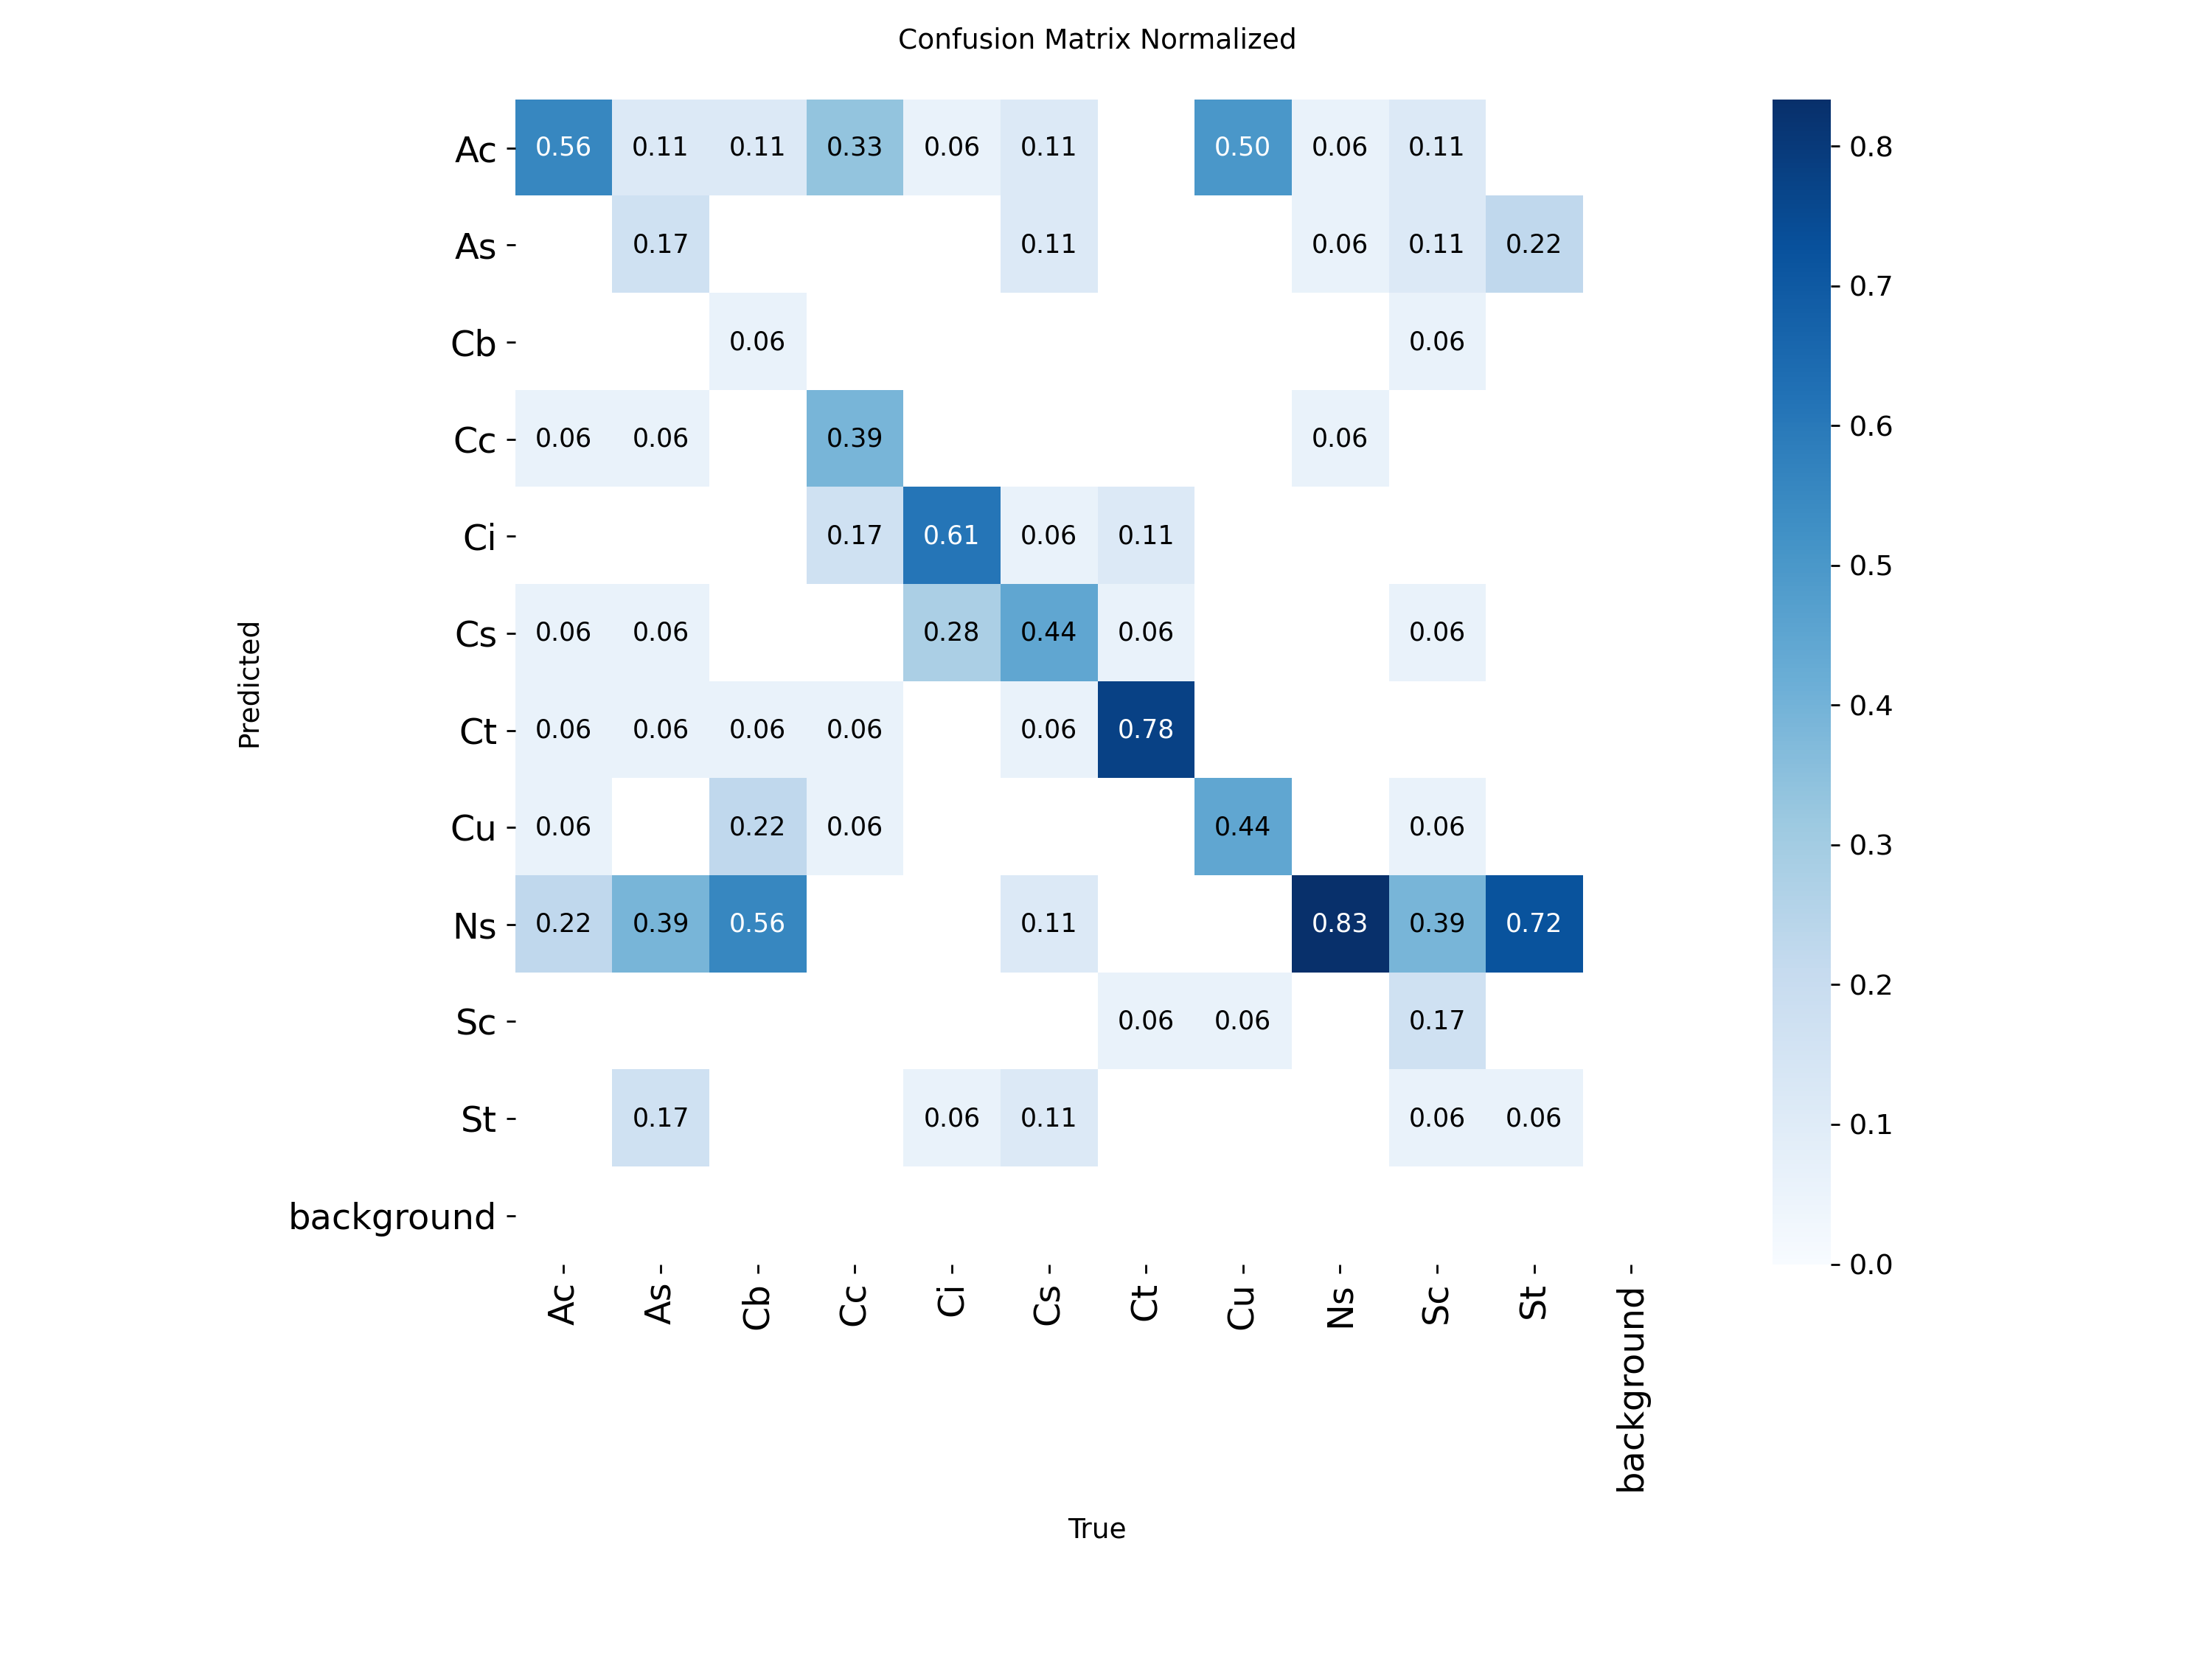

In [ ]:
%matplotlib inline
from PIL import Image

Image.open("C:/Users/Selena/runs/classify/val/confusion_matrix_normalized.png")

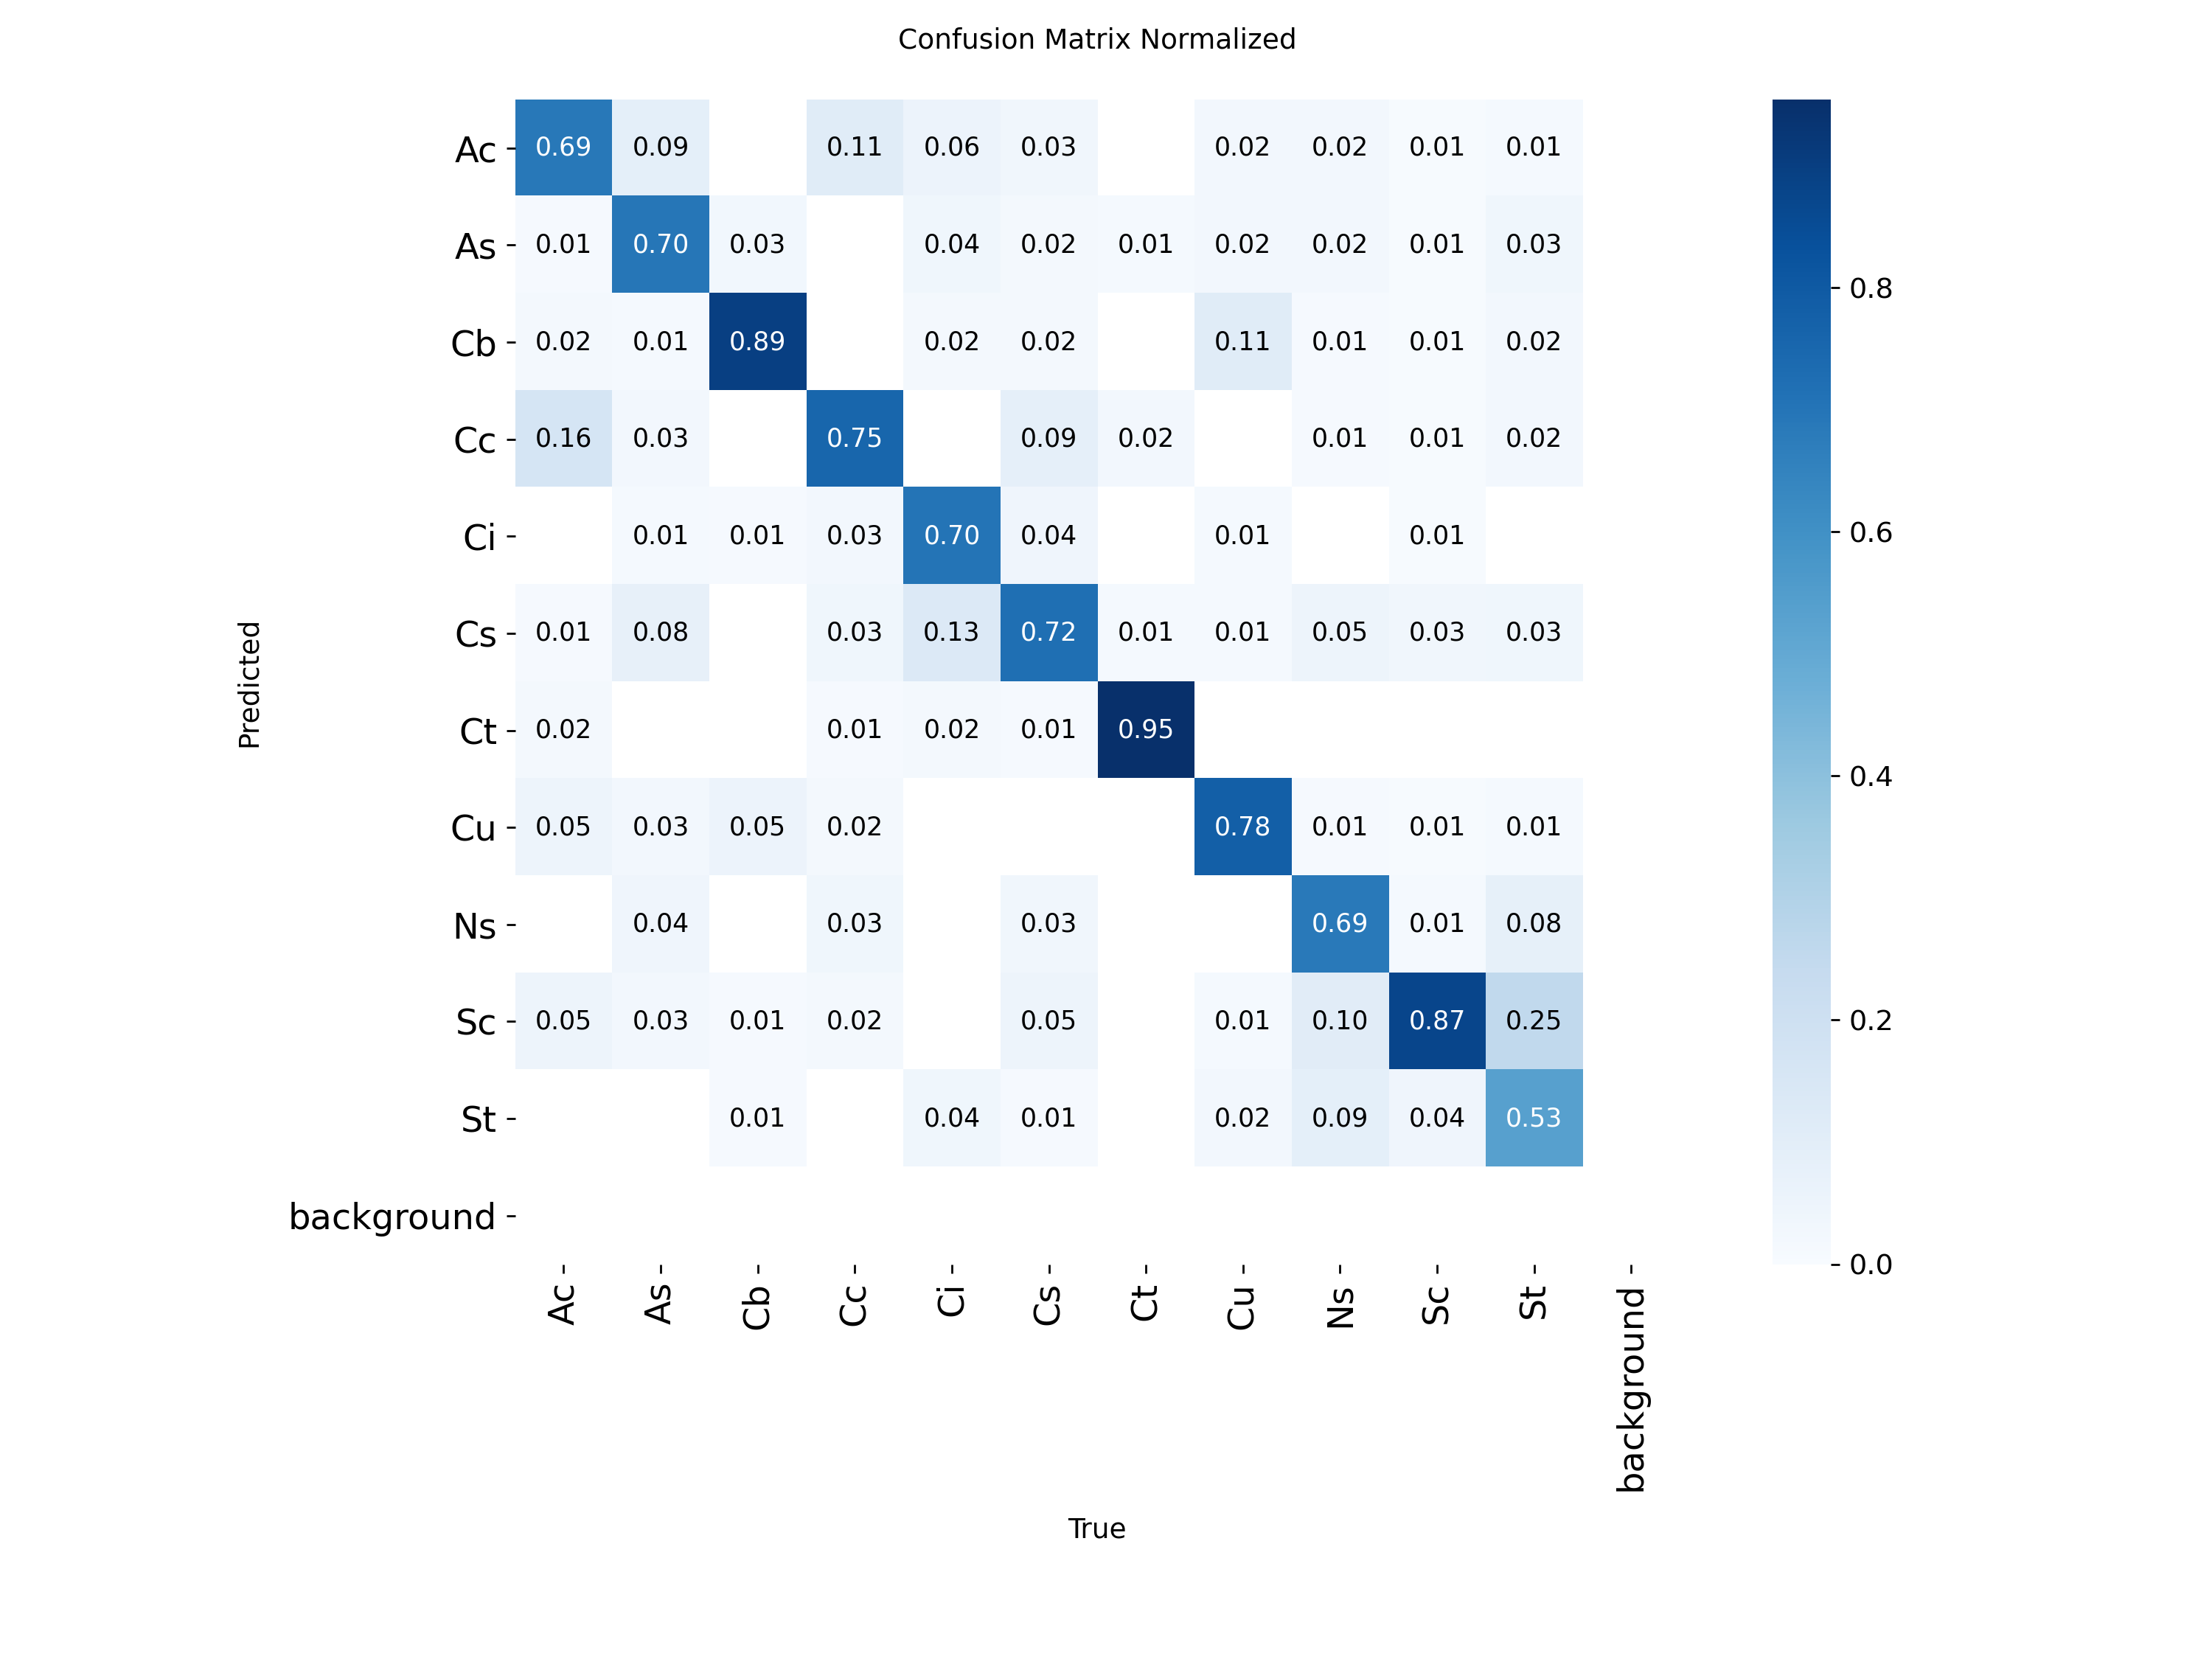

In [ ]:
%matplotlib inline
from PIL import Image

Image.open("C:/Users/selen/runs/classify/val5/confusion_matrix_normalized.png")

In [ ]:
model_tuned = YOLO("C:/Users/selen/runs/classify/train3/weights/best.pt")  # load a custom model
metrics_test = model_tuned.val(data="S:/important_backup/school_backup/iat360/archive/data/val/val-20251103T042459Z-1-001/val")

Ultralytics 8.3.218  Python-3.13.7 torch-2.9.0+cpu CPU (AMD Ryzen 7 PRO 5875U with Radeon Graphics)
YOLO11s-cls summary (fused): 47 layers, 5,448,219 parameters, 0 gradients, 12.0 GFLOPs
WARNING Dataset 'split=train' not found at S:\important_backup\school_backup\iat360\archive\data\val\val-20251103T042459Z-1-001\val\train
Found 157 images in subdirectories. Attempting to split...
Splitting S:\important_backup\school_backup\iat360\archive\data\val\val-20251103T042459Z-1-001\val (11 classes, 202 images) into 80% train, 20% val...
Split complete in S:\important_backup\school_backup\iat360\archive\data\val\val-20251103T042459Z-1-001\val_split 
train: S:\important_backup\school_backup\iat360\archive\data\val\val-20251103T042459Z-1-001\val_split\train... found 157 images in 11 classes  
val: S:\important_backup\school_backup\iat360\archive\data\val\val-20251103T042459Z-1-001\val_split\val... found 45 images in 11 classes  
test: None...
val: Fast image access  (ping: 0.10.0 ms, read: 149.31

##Prediction

In [ ]:
model = YOLO("C:/Users/Selena/runs/classify/train/weights/best.pt")  # load a custom model

# Predict with the model with any image from internet?
results = model("C:/Users/Selena/Documents/school/iat360/cv_project/data_original_valupdate/data/test/Ac", save=True)



image 1/24 C:\Users\Selena\Documents\school\iat360\cv_project\data_original_valupdate\data\test\Ac\108.jpg: 416x416 Cb 0.51, St 0.15, Sc 0.13, Cu 0.07, Ac 0.05, 24.0ms
image 2/24 C:\Users\Selena\Documents\school\iat360\cv_project\data_original_valupdate\data\test\Ac\11.jpg: 416x416 Ac 0.48, As 0.34, Cc 0.10, Ns 0.03, Ci 0.01, 22.9ms
image 3/24 C:\Users\Selena\Documents\school\iat360\cv_project\data_original_valupdate\data\test\Ac\125.jpg: 416x416 Ac 0.32, As 0.27, Cc 0.13, Sc 0.09, Cs 0.07, 24.0ms
image 4/24 C:\Users\Selena\Documents\school\iat360\cv_project\data_original_valupdate\data\test\Ac\126.jpg: 416x416 Ac 0.68, Cc 0.22, Ci 0.03, Cs 0.02, St 0.01, 23.8ms
image 5/24 C:\Users\Selena\Documents\school\iat360\cv_project\data_original_valupdate\data\test\Ac\137.jpg: 416x416 As 0.61, Ac 0.24, Ns 0.04, Sc 0.04, Ci 0.02, 23.0ms
image 6/24 C:\Users\Selena\Documents\school\iat360\cv_project\data_original_valupdate\data\test\Ac\143.jpg: 416x416 Sc 0.36, Cu 0.27, Cb 0.17, St 0.07, Ac 0.05,

In [ ]:
results = model("C:/Users/Selena/Documents/school/iat360/cv_project/data_original_valupdate/data/test/As", save=True)



image 1/4 C:\Users\Selena\Documents\school\iat360\cv_project\data_original_valupdate\data\test\As\107.jpg: 416x416 Ns 0.32, Cb 0.17, Cu 0.16, Ac 0.09, St 0.09, 24.0ms
image 2/4 C:\Users\Selena\Documents\school\iat360\cv_project\data_original_valupdate\data\test\As\158.jpg: 416x416 Ns 0.38, Cs 0.24, St 0.16, Sc 0.08, Ac 0.05, 22.2ms
image 3/4 C:\Users\Selena\Documents\school\iat360\cv_project\data_original_valupdate\data\test\As\181.jpg: 416x416 Ns 0.55, St 0.18, As 0.13, Cs 0.11, Ac 0.03, 21.8ms
image 4/4 C:\Users\Selena\Documents\school\iat360\cv_project\data_original_valupdate\data\test\As\47.jpg: 416x416 St 0.39, Ns 0.31, Sc 0.21, As 0.04, Cb 0.02, 21.6ms
Speed: 2.6ms preprocess, 22.4ms inference, 0.0ms postprocess per image at shape (1, 3, 416, 416)
Results saved to C:\Users\Selena\runs\classify\predict


In [ ]:
results = model("C:/Users/Selena/Documents/school/iat360/cv_project/data_original_valupdate/data/test/Cc", save=True)



image 1/12 C:\Users\Selena\Documents\school\iat360\cv_project\data_original_valupdate\data\test\Cc\115.jpg: 416x416 Cc 0.86, Ac 0.04, Cs 0.03, Ci 0.03, Ct 0.02, 23.5ms
image 2/12 C:\Users\Selena\Documents\school\iat360\cv_project\data_original_valupdate\data\test\Cc\139.jpg: 416x416 Ac 0.68, Cc 0.29, Cs 0.01, As 0.00, Ct 0.00, 41.0ms
image 3/12 C:\Users\Selena\Documents\school\iat360\cv_project\data_original_valupdate\data\test\Cc\146.jpg: 416x416 Ac 0.77, Cc 0.17, Ns 0.02, Cu 0.01, St 0.01, 21.9ms
image 4/12 C:\Users\Selena\Documents\school\iat360\cv_project\data_original_valupdate\data\test\Cc\148.jpg: 416x416 Cc 0.41, Ac 0.32, Ns 0.09, Cs 0.08, Ci 0.05, 22.0ms
image 5/12 C:\Users\Selena\Documents\school\iat360\cv_project\data_original_valupdate\data\test\Cc\159.jpg: 416x416 As 0.85, Ac 0.12, Cs 0.01, Cc 0.01, Sc 0.01, 22.2ms
image 6/12 C:\Users\Selena\Documents\school\iat360\cv_project\data_original_valupdate\data\test\Cc\166.jpg: 416x416 Cc 0.38, Ct 0.32, Ci 0.19, Cs 0.07, As 0.01

In [ ]:
results = model("C:/Users/Selena/Documents/school/iat360/cv_project/data_original_valupdate/data/test/Ci", save=True)



image 1/33 C:\Users\Selena\Documents\school\iat360\cv_project\data_original_valupdate\data\test\Ci\110.jpg: 416x416 Sc 0.65, St 0.14, Cs 0.08, As 0.03, Ns 0.02, 24.6ms
image 2/33 C:\Users\Selena\Documents\school\iat360\cv_project\data_original_valupdate\data\test\Ci\113.jpg: 416x416 Cs 0.20, Cc 0.17, Ci 0.16, Ns 0.15, As 0.10, 21.9ms
image 3/33 C:\Users\Selena\Documents\school\iat360\cv_project\data_original_valupdate\data\test\Ci\116.jpg: 416x416 Ct 0.89, Cs 0.06, Ac 0.04, As 0.01, Ci 0.00, 22.6ms
image 4/33 C:\Users\Selena\Documents\school\iat360\cv_project\data_original_valupdate\data\test\Ci\12.jpg: 416x416 Cs 0.43, Ci 0.23, Ct 0.17, Cc 0.12, Ac 0.03, 21.2ms
image 5/33 C:\Users\Selena\Documents\school\iat360\cv_project\data_original_valupdate\data\test\Ci\128.jpg: 416x416 Cc 0.93, Ac 0.04, Cs 0.01, Ci 0.01, Ns 0.01, 21.0ms
image 6/33 C:\Users\Selena\Documents\school\iat360\cv_project\data_original_valupdate\data\test\Ci\129.jpg: 416x416 Cs 0.67, Ac 0.16, Ci 0.09, Cc 0.02, As 0.02,

In [ ]:
results = model("C:/Users/Selena/Documents/school/iat360/cv_project/data_original_valupdate/data/test/Cu", save=True)



image 1/20 C:\Users\Selena\Documents\school\iat360\cv_project\data_original_valupdate\data\test\Cu\10.jpg: 416x416 Cu 0.78, Cb 0.22, St 0.00, As 0.00, Ac 0.00, 22.4ms
image 2/20 C:\Users\Selena\Documents\school\iat360\cv_project\data_original_valupdate\data\test\Cu\101.jpg: 416x416 Cu 0.71, Cb 0.26, St 0.01, Sc 0.01, Ac 0.00, 21.7ms
image 3/20 C:\Users\Selena\Documents\school\iat360\cv_project\data_original_valupdate\data\test\Cu\123.jpg: 416x416 Cc 0.42, Ac 0.17, Cu 0.12, Ci 0.10, St 0.08, 22.5ms
image 4/20 C:\Users\Selena\Documents\school\iat360\cv_project\data_original_valupdate\data\test\Cu\130.jpg: 416x416 Cu 0.77, Cb 0.11, As 0.03, Ac 0.03, St 0.02, 21.8ms
image 5/20 C:\Users\Selena\Documents\school\iat360\cv_project\data_original_valupdate\data\test\Cu\136.jpg: 416x416 Cu 0.77, Cb 0.13, St 0.04, As 0.04, Ac 0.01, 21.1ms
image 6/20 C:\Users\Selena\Documents\school\iat360\cv_project\data_original_valupdate\data\test\Cu\156.jpg: 416x416 Cu 0.28, Ac 0.28, Cb 0.17, Ns 0.09, St 0.08,

In [ ]:
results = model("C:/Users/Selena/Documents/school/iat360/cv_project/data_original_valupdate/data/test/Cb", save=True)



image 1/26 C:\Users\Selena\Documents\school\iat360\cv_project\data_original_valupdate\data\test\Cb\1.jpg: 416x416 Cb 0.55, Sc 0.17, Cu 0.13, St 0.12, Ns 0.01, 22.9ms
image 2/26 C:\Users\Selena\Documents\school\iat360\cv_project\data_original_valupdate\data\test\Cb\103.jpg: 416x416 Cb 0.32, Cu 0.23, Ns 0.19, St 0.09, Ac 0.08, 22.3ms
image 3/26 C:\Users\Selena\Documents\school\iat360\cv_project\data_original_valupdate\data\test\Cb\114.jpg: 416x416 Cb 0.57, Cu 0.30, St 0.05, As 0.03, Ns 0.03, 22.5ms
image 4/26 C:\Users\Selena\Documents\school\iat360\cv_project\data_original_valupdate\data\test\Cb\120.jpg: 416x416 St 0.77, Cu 0.09, Sc 0.07, Cb 0.05, Ns 0.02, 21.9ms
image 5/26 C:\Users\Selena\Documents\school\iat360\cv_project\data_original_valupdate\data\test\Cb\127.jpg: 416x416 St 0.46, Sc 0.25, Ns 0.08, Cs 0.07, Cu 0.04, 20.9ms
image 6/26 C:\Users\Selena\Documents\school\iat360\cv_project\data_original_valupdate\data\test\Cb\134.jpg: 416x416 Cb 0.66, Cu 0.28, Ac 0.02, As 0.01, St 0.01, 

In [ ]:
results = model("C:/Users/Selena/Documents/school/iat360/cv_project/data_original_valupdate/data/test/Ns", save=True)



image 1/11 C:\Users\Selena\Documents\school\iat360\cv_project\data_original_valupdate\data\test\Ns\111.jpg: 416x416 Ns 0.46, Ac 0.18, As 0.10, St 0.09, Cs 0.05, 23.6ms
image 2/11 C:\Users\Selena\Documents\school\iat360\cv_project\data_original_valupdate\data\test\Ns\135.jpg: 416x416 Cu 0.80, Cb 0.15, As 0.01, Sc 0.01, St 0.01, 21.7ms
image 3/11 C:\Users\Selena\Documents\school\iat360\cv_project\data_original_valupdate\data\test\Ns\14.jpg: 416x416 Ns 0.67, Ac 0.13, As 0.07, Ct 0.03, Sc 0.03, 22.0ms
image 4/11 C:\Users\Selena\Documents\school\iat360\cv_project\data_original_valupdate\data\test\Ns\16.jpg: 416x416 Ac 0.26, Cu 0.23, Cb 0.21, Ns 0.08, Ci 0.05, 22.9ms
image 5/11 C:\Users\Selena\Documents\school\iat360\cv_project\data_original_valupdate\data\test\Ns\175.jpg: 416x416 Ns 0.29, Sc 0.21, St 0.17, Cs 0.13, Cc 0.04, 21.8ms
image 6/11 C:\Users\Selena\Documents\school\iat360\cv_project\data_original_valupdate\data\test\Ns\191.jpg: 416x416 Ns 0.48, St 0.14, Sc 0.14, Cs 0.08, As 0.06, 

In [ ]:
results = model("C:/Users/Selena/Documents/school/iat360/cv_project/data_original_valupdate/data/test/Cs", save=True)



image 1/5 C:\Users\Selena\Documents\school\iat360\cv_project\data_original_valupdate\data\test\Cs\117.jpg: 416x416 Ac 0.45, Ct 0.16, Cs 0.11, Ns 0.08, Cc 0.07, 24.8ms
image 2/5 C:\Users\Selena\Documents\school\iat360\cv_project\data_original_valupdate\data\test\Cs\124.jpg: 416x416 Ns 0.50, Cs 0.28, Ac 0.08, As 0.06, Sc 0.02, 22.1ms
image 3/5 C:\Users\Selena\Documents\school\iat360\cv_project\data_original_valupdate\data\test\Cs\151.jpg: 416x416 Cs 0.61, Cc 0.14, Ci 0.06, St 0.05, As 0.04, 21.3ms
image 4/5 C:\Users\Selena\Documents\school\iat360\cv_project\data_original_valupdate\data\test\Cs\167.jpg: 416x416 Ci 0.58, Cs 0.34, Ac 0.06, Cc 0.01, Ct 0.01, 22.7ms
image 5/5 C:\Users\Selena\Documents\school\iat360\cv_project\data_original_valupdate\data\test\Cs\83.jpg: 416x416 Ct 0.58, Cs 0.25, Ac 0.05, Ci 0.04, Cc 0.03, 22.6ms
Speed: 2.3ms preprocess, 22.7ms inference, 0.0ms postprocess per image at shape (1, 3, 416, 416)
Results saved to C:\Users\Selena\runs\classify\predict


In [ ]:
results = model("C:/Users/Selena/Documents/school/iat360/cv_project/data_original_valupdate/data/test/St", save=True)
# results = model("C:/Users/Selena/Documents/school/iat360/cv_project/data_original_valupdate/data/test/Ct", save=True)
# results = model("C:/Users/Selena/Documents/school/iat360/cv_project/data_original_valupdate/data/test/Sc", save=True)


image 1/16 C:\Users\Selena\Documents\school\iat360\cv_project\data_original_valupdate\data\test\St\104.jpg: 416x416 Ns 0.44, Ac 0.24, As 0.13, Cs 0.07, Sc 0.03, 23.5ms
image 2/16 C:\Users\Selena\Documents\school\iat360\cv_project\data_original_valupdate\data\test\St\112.jpg: 416x416 Cb 0.33, Cu 0.16, Ac 0.15, St 0.12, Ns 0.09, 22.7ms
image 3/16 C:\Users\Selena\Documents\school\iat360\cv_project\data_original_valupdate\data\test\St\18.jpg: 416x416 Ns 0.41, Sc 0.36, St 0.14, As 0.03, Cb 0.02, 21.7ms
image 4/16 C:\Users\Selena\Documents\school\iat360\cv_project\data_original_valupdate\data\test\St\197.jpg: 416x416 Sc 0.44, St 0.27, Ns 0.11, Cb 0.09, Cu 0.04, 27.6ms
image 5/16 C:\Users\Selena\Documents\school\iat360\cv_project\data_original_valupdate\data\test\St\198.jpg: 416x416 Ns 0.30, St 0.14, Sc 0.12, As 0.11, Cs 0.10, 22.6ms
image 6/16 C:\Users\Selena\Documents\school\iat360\cv_project\data_original_valupdate\data\test\St\207.jpg: 416x416 Ns 0.41, Ac 0.19, As 0.15, St 0.09, Cu 0.07,

In [ ]:
results = model("C:/Users/Selena/Documents/school/iat360/cv_project/data_original_valupdate/data/test/Ct", save=True)



image 1/16 C:\Users\Selena\Documents\school\iat360\cv_project\data_original_valupdate\data\test\Ct\100.jpg: 416x416 Ct 0.42, Cu 0.30, Cb 0.13, Ac 0.07, St 0.03, 22.8ms
image 2/16 C:\Users\Selena\Documents\school\iat360\cv_project\data_original_valupdate\data\test\Ct\106.jpg: 416x416 Ct 0.99, Ac 0.00, Cs 0.00, Cc 0.00, Ci 0.00, 22.1ms
image 3/16 C:\Users\Selena\Documents\school\iat360\cv_project\data_original_valupdate\data\test\Ct\133.jpg: 416x416 Ct 0.97, Cs 0.01, Ci 0.00, Ns 0.00, As 0.00, 23.0ms
image 4/16 C:\Users\Selena\Documents\school\iat360\cv_project\data_original_valupdate\data\test\Ct\138.jpg: 416x416 Ct 0.54, Ci 0.26, Ac 0.11, Cs 0.05, Ns 0.01, 22.2ms
image 5/16 C:\Users\Selena\Documents\school\iat360\cv_project\data_original_valupdate\data\test\Ct\15.jpg: 416x416 Ct 0.97, Ci 0.02, Cs 0.01, Ac 0.00, St 0.00, 22.0ms
image 6/16 C:\Users\Selena\Documents\school\iat360\cv_project\data_original_valupdate\data\test\Ct\163.jpg: 416x416 Ct 1.00, Cs 0.00, Ac 0.00, Ci 0.00, Cc 0.00,

In [ ]:
results = model("C:/Users/Selena/Documents/school/iat360/cv_project/data_original_valupdate/data/test/Sc", save=True)


image 1/42 C:\Users\Selena\Documents\school\iat360\cv_project\data_original_valupdate\data\test\Sc\102.jpg: 416x416 Ac 0.21, Cb 0.17, Ns 0.17, Cu 0.13, St 0.13, 23.5ms
image 2/42 C:\Users\Selena\Documents\school\iat360\cv_project\data_original_valupdate\data\test\Sc\105.jpg: 416x416 Sc 0.42, St 0.27, Ns 0.12, Ac 0.07, Cu 0.03, 24.1ms
image 3/42 C:\Users\Selena\Documents\school\iat360\cv_project\data_original_valupdate\data\test\Sc\109.jpg: 416x416 Ac 0.43, Cc 0.14, Cb 0.11, Ns 0.10, As 0.04, 22.1ms
image 4/42 C:\Users\Selena\Documents\school\iat360\cv_project\data_original_valupdate\data\test\Sc\118.jpg: 416x416 Sc 0.49, Ns 0.21, St 0.16, Ac 0.03, Cs 0.03, 21.9ms
image 5/42 C:\Users\Selena\Documents\school\iat360\cv_project\data_original_valupdate\data\test\Sc\119.jpg: 416x416 Sc 0.90, St 0.05, Ns 0.04, Cs 0.01, Cb 0.00, 21.0ms
image 6/42 C:\Users\Selena\Documents\school\iat360\cv_project\data_original_valupdate\data\test\Sc\121.jpg: 416x416 Ns 0.27, Sc 0.18, Ac 0.16, As 0.16, St 0.09

In [ ]:
model_tuned = YOLO("C:/Users/selen/runs/classify/train3/weights/best.pt")  # load a custom model

In [ ]:
results_tuned = model_tuned("S:/important_backup/school_backup/iat360/archive/data/test/Ac", save=True)


image 1/24 S:\important_backup\school_backup\iat360\archive\data\test\Ac\108.jpg: 640x640 Ac 0.76, Cc 0.09, Cb 0.05, Cs 0.03, Cu 0.02, 113.4ms
image 2/24 S:\important_backup\school_backup\iat360\archive\data\test\Ac\11.jpg: 640x640 Ac 0.84, Cc 0.12, Sc 0.02, As 0.01, St 0.00, 88.3ms
image 3/24 S:\important_backup\school_backup\iat360\archive\data\test\Ac\125.jpg: 640x640 Ac 0.94, Cc 0.05, As 0.01, Sc 0.00, Cs 0.00, 86.1ms
image 4/24 S:\important_backup\school_backup\iat360\archive\data\test\Ac\126.jpg: 640x640 Ac 0.47, Cs 0.26, Cc 0.22, Cu 0.02, Cb 0.01, 90.1ms
image 5/24 S:\important_backup\school_backup\iat360\archive\data\test\Ac\137.jpg: 640x640 As 0.99, Sc 0.00, St 0.00, Ac 0.00, Cu 0.00, 91.0ms
image 6/24 S:\important_backup\school_backup\iat360\archive\data\test\Ac\143.jpg: 640x640 Sc 0.91, Cs 0.05, Cc 0.03, Ci 0.01, St 0.00, 109.6ms
image 7/24 S:\important_backup\school_backup\iat360\archive\data\test\Ac\144.jpg: 640x640 As 0.78, Sc 0.09, Cs 0.09, Ac 0.01, St 0.01, 113.5ms
ima

In [ ]:
results_tuned = model_tuned("S:/important_backup/school_backup/iat360/archive/data/test/As", save=True)


image 1/4 S:\important_backup\school_backup\iat360\archive\data\test\As\107.jpg: 640x640 Cu 0.40, St 0.31, Cb 0.20, Ac 0.06, Ns 0.01, 90.8ms
image 2/4 S:\important_backup\school_backup\iat360\archive\data\test\As\158.jpg: 640x640 Cs 0.82, St 0.10, Sc 0.05, As 0.01, Ns 0.01, 90.8ms
image 3/4 S:\important_backup\school_backup\iat360\archive\data\test\As\181.jpg: 640x640 Cs 0.94, As 0.05, St 0.00, Cc 0.00, Ac 0.00, 91.1ms
image 4/4 S:\important_backup\school_backup\iat360\archive\data\test\As\47.jpg: 640x640 Ns 0.42, Sc 0.41, St 0.15, Cs 0.01, As 0.00, 101.0ms
Speed: 8.5ms preprocess, 93.4ms inference, 0.0ms postprocess per image at shape (1, 3, 640, 640)
Results saved to C:\Users\selen\runs\classify\predict


In [25]:
results_tuned = model_tuned("S:/important_backup/school_backup/iat360/archive/data/test/Cb", save=True)

FileNotFoundError: S:/important_backup/school_backup/iat360/archive/data/test/Cb does not exist

In [27]:
model = YOLO("/content/runs/classify/train2/weights/best.pt")  # load a custom model

Ac = model("/content/drive/MyDrive/archive (2)/data/test/Ac/126.jpg", save=True)
As = model("/content/drive/MyDrive/archive (2)/data/test/As/158.jpg", save=True)
Cb = model("/content/drive/MyDrive/archive (2)/data/test/Cb/127.jpg", save=True)
Cc = model("/content/drive/MyDrive/archive (2)/data/test/Cc/139.jpg", save=True)
Ci = model("/content/drive/MyDrive/archive (2)/data/test/Ci/113.jpg", save=True)
Cs = model("/content/drive/MyDrive/archive (2)/data/test/Cs/124.jpg", save=True)
Ct = model("/content/drive/MyDrive/archive (2)/data/test/Ct/100.jpg", save=True)
Cu = model("/content/drive/MyDrive/archive (2)/data/test/Cu/123.jpg", save=True)
Ns = model("/content/drive/MyDrive/archive (2)/data/test/Ns/111.jpg", save=True)
Sc = model("/content/drive/MyDrive/archive (2)/data/test/Sc/102.jpg", save=True)
St = model("/content/drive/MyDrive/archive (2)/data/test/St/104.jpg", save=True)



image 1/1 /content/drive/MyDrive/archive (2)/data/test/Ac/126.jpg: 416x416 Ac 0.91, Cc 0.07, Cb 0.01, Cu 0.00, Cs 0.00, 5.4ms
Speed: 7.8ms preprocess, 5.4ms inference, 0.0ms postprocess per image at shape (1, 3, 416, 416)
Results saved to /content/runs/classify/predict2

image 1/1 /content/drive/MyDrive/archive (2)/data/test/As/158.jpg: 416x416 St 0.57, Cs 0.30, Ns 0.10, As 0.02, Cc 0.01, 5.4ms
Speed: 5.4ms preprocess, 5.4ms inference, 0.0ms postprocess per image at shape (1, 3, 416, 416)
Results saved to /content/runs/classify/predict2

image 1/1 /content/drive/MyDrive/archive (2)/data/test/Cb/127.jpg: 416x416 Sc 0.90, Cs 0.08, St 0.01, Ns 0.01, Ci 0.01, 5.5ms
Speed: 5.4ms preprocess, 5.5ms inference, 0.0ms postprocess per image at shape (1, 3, 416, 416)
Results saved to /content/runs/classify/predict2

image 1/1 /content/drive/MyDrive/archive (2)/data/test/Cc/139.jpg: 416x416 Cc 0.69, Ac 0.25, Ct 0.03, Cu 0.01, Ci 0.01, 5.4ms
Speed: 6.2ms preprocess, 5.4ms inference, 0.0ms postproce

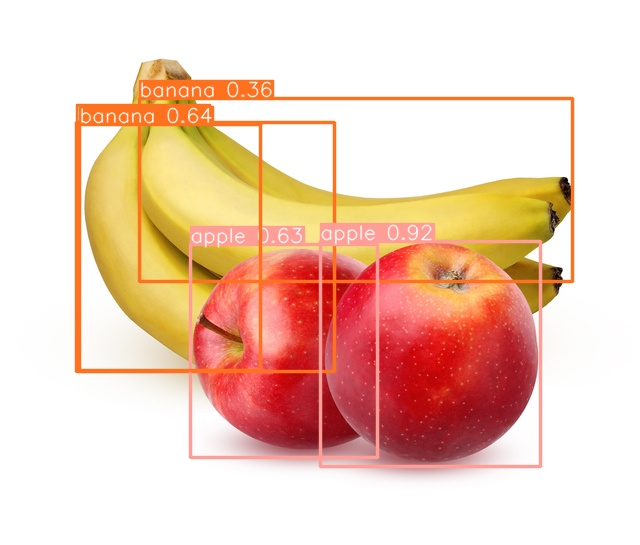

In [ ]:
# SHOW THE IMAGE STORED
%matplotlib inline
from PIL import Image

Image.open('/content/runs/detect/predict/freshpoint-produce-101-apples-bananas.jpg')